# Lab 8

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from scipy.optimize import newton, brentq

## Zadanie 1

In [4]:
x = sp.symbols('x')
alpha = 2

phi_exprs = [
    (x**2 + 2) / 3,
    sp.sqrt(3*x - 2),
    3 - 2/x,
    (x**2 - 2) / (2*x - 3)
]

orders_theory = []

for i, phi_expr in enumerate(phi_exprs, start=1):
    derivative = sp.diff(phi_expr, x)
    value = sp.simplify(derivative.subs(x, alpha))
    abs_value = abs(value)

    if abs_value > 1:
        order = -1
    elif abs_value < 1:
        if value != 0:
            order = 1
        else:
            order = 0
            for p in range(2, 10):
                next_derivative = sp.diff(phi_expr, x, p)
                next_value = sp.simplify(next_derivative.subs(x, alpha))
                if next_value != 0:
                    order = p
                    break
    else:
        order = 0

    orders_theory.append(order)
    print('phi' + str(i), '|phi prim(2)| =', abs_value, 'rzad =', order)

phi1 |phi prim(2)| = 4/3 rzad = -1
phi2 |phi prim(2)| = 3/4 rzad = 1
phi3 |phi prim(2)| = 1/2 rzad = 1
phi4 |phi prim(2)| = 0 rzad = 2


In [5]:
alpha = 2.0
start = 1.9
iterations = 10


def phi1(value):
    return (value**2 + 2) / 3


def phi2(value):
    return math.sqrt(3*value - 2)


def phi3(value):
    return 3 - 2/value


def phi4(value):
    return (value**2 - 2) / (2*value - 3)


phi_functions = [phi1, phi2, phi3, phi4]
all_abs_errors = {}
all_rel_errors = {}
all_values = {}

for i, phi in enumerate(phi_functions, start=1):
    value = start
    values = [value]
    abs_errors = [abs(value - alpha)]
    rel_errors = [abs(value - alpha) / abs(alpha)]

    for k in range(1, iterations + 1):
        value = phi(value)
        values.append(value)
        abs_errors.append(abs(value - alpha))
        rel_errors.append(abs(value - alpha) / abs(alpha))

    all_values[i] = values
    all_abs_errors[i] = abs_errors
    all_rel_errors[i] = rel_errors

    print('phi' + str(i))
    print('iteracja        x              blad_bezwzgledny     blad_wzgledny')
    for k in range(iterations + 1):
        print(k, '       ', values[k], '       ', abs_errors[k], '       ', rel_errors[k])
    print()

phi1
iteracja        x              blad_bezwzgledny     blad_wzgledny
0         1.9         0.10000000000000009         0.050000000000000044
1         1.8699999999999999         0.13000000000000012         0.06500000000000006
2         1.8323         0.16769999999999996         0.08384999999999998
3         1.78577443         0.21422556999999998         0.10711278499999999
4         1.7296634382806084         0.2703365617193916         0.1351682808596958
5         1.663911869908232         0.33608813009176797         0.16804406504588398
6         1.5895342369405032         0.4104657630594968         0.2052328815297484
7         1.5088730301353426         0.4911269698646574         0.2455634849323287
8         1.4255659403566032         0.5744340596433968         0.2872170298216984
9         1.3440794167682686         0.6559205832317314         0.3279602916158657
10         1.2688498261933763         0.7311501738066237         0.36557508690331186

phi2
iteracja        x              bl

In [6]:
orders_exp = []

for i in range(1, 5):
    errors = all_abs_errors[i]

    if orders_theory[i - 1] == -1:
        order = -1
    else:
        order_values = []

        for k in range(1, len(errors) - 1):
            e_prev = errors[k - 1]
            e_now = errors[k]
            e_next = errors[k + 1]

            if e_prev > 0 and e_now > 0 and e_next > 0:
                bottom = math.log(e_prev / e_now)

                if bottom != 0:
                    order_k = math.log(e_now / e_next) / bottom

                    if math.isfinite(order_k):
                        order_values.append(order_k)

        if len(order_values) > 0:
            order = order_values[-1]
        else:
            order = 0

    orders_exp.append(order)
    print('phi' + str(i), 'rzad eksperymentalny =', round(order, 3))

phi1 rzad eksperymentalny = -1
phi2 rzad eksperymentalny = 1.002
phi3 rzad eksperymentalny = 1.0
phi4 rzad eksperymentalny = 1.943


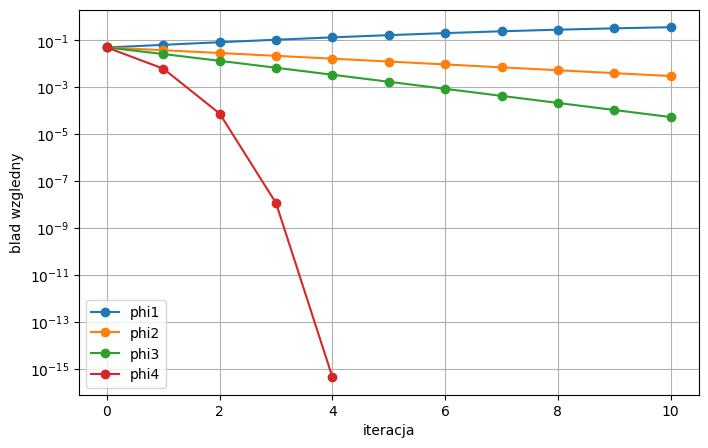

In [7]:
iteration_numbers = np.arange(iterations + 1)

plt.figure(figsize=(8, 5))

for i in range(1, 5):
    errors = np.array(all_rel_errors[i], dtype=float)
    errors[errors == 0] = np.nan
    plt.semilogy(iteration_numbers, errors, marker='o', label='phi' + str(i))

plt.xlabel('iteracja')
plt.ylabel('blad wzgledny')
plt.grid(True)
plt.legend()
plt.show()

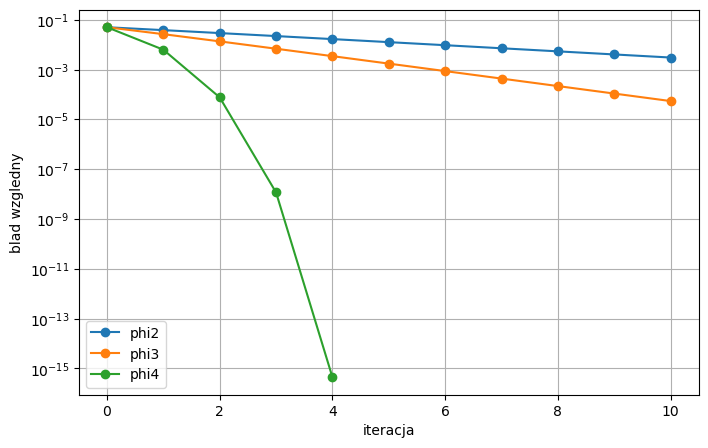

In [34]:
plt.figure(figsize=(8, 5))

for i, order in enumerate(orders_theory, start=1):
    if order > 0:
        errors = np.array(all_rel_errors[i], dtype=float)
        errors[errors == 0] = np.nan
        plt.semilogy(iteration_numbers, errors, marker='o', label='phi' + str(i))

plt.xlabel('iteracja')
plt.ylabel('blad wzgledny')
plt.grid(True)
plt.legend()
plt.savefig("plot2.png", dpi=300, bbox_inches="tight")
plt.show()


## Zadanie 2

In [10]:
def f_a(value):
    return value**3 - 5*value


def df_a(value):
    return 3*value**2 - 5


def f_b(value):
    return value**3 - 3*value + 1


def df_b(value):
    return 3*value**2 - 3


def f_c(value):
    return 2 - value**5


def df_c(value):
    return -5*value**4


def f_d(value):
    return value**4 - 4.29*value**2 - 5.29


def df_d(value):
    return 4*value**3 - 8.58*value


cases = [
    (
        'a',
        f_a,
        df_a,
        1.0,
        [(-3, -1), (-1, 1), (1, 3)],
        [(-3, -2), (-0.5, 0.5), (2, 3)],
        'dla x0 = 1 metoda Newtona przechodzi do -1, a potem wraca do 1, czyli wpada w cykl',
    ),
    (
        'b',
        f_b,
        df_b,
        1.0,
        [(-3, -1), (0, 1), (1, 2)],
        [(-2, -1), (0, 0.5), (1.5, 2)],
        'w punkcie x0 = 1 pochodna jest rowna 0, wiec klasyczny krok Newtona nie jest okreslony',
    ),
    (
        'c',
        f_c,
        df_c,
        0.01,
        [(0, 2)],
        [(1, 2)],
        'dla x0 = 0.01 pochodna jest bardzo mala, wiec pierwszy krok Newtona jest ogromny',
    ),
    (
        'd',
        f_d,
        df_d,
        0.8,
        [(-3, -1), (1, 3)],
        [(-3, -2), (2, 3)],
        'iteracje z x0 = 0.8 wpadaja w oscylacje w okolicach +/-0.7876, ktore nie sa pierwiastkami',
    ),
]


def append_unique(roots, new_root, tolerance=1e-8):
    if abs(new_root.imag) > tolerance:
        return

    new_root = float(new_root.real)

    if not any(abs(new_root - old_root) < tolerance for old_root in roots):
        roots.append(new_root)


for name, func, dfunc, start, intervals, secant_starts, reason in cases:
    print('przypadek', name)
    print('powod awarii:', reason)

    try:
        root = newton(func, start, fprime=dfunc, maxiter=20)
        print('newton klasyczny =', root)
    except Exception as error:
        print('newton klasyczny =', type(error).__name__)

    roots_newton_modified = []

    for x0_modified, x1_modified in secant_starts:
        try:
            # Modyfikacja wywolania scipy.optimize.newton:
            # bez fprime, ale z drugim punktem startowym x1, czyli metoda siecznych.
            root = newton(func, x0=x0_modified, x1=x1_modified, maxiter=50, tol=1e-12)

            if abs(func(root)) < 1e-8:
                append_unique(roots_newton_modified, root)
        except Exception:
            pass

    roots_newton_modified.sort()
    print('newton zmodyfikowany, metoda siecznych =', roots_newton_modified)

    # Metoda brentq jako metoda zapasowa i jednoczesnie kontrola znalezionych pierwiastkow.
    roots_brentq = []

    for left, right in intervals:
        try:
            root = brentq(func, left, right)
            append_unique(roots_brentq, root)
        except ValueError:
            pass

    roots_brentq.sort()
    print('brentq =', roots_brentq)
    print()

przypadek a
powod awarii: dla x0 = 1 metoda Newtona przechodzi do -1, a potem wraca do 1, czyli wpada w cykl
newton klasyczny = RuntimeError
newton zmodyfikowany, metoda siecznych = [-2.23606797749979, 0.0, 2.23606797749979]
brentq = [-2.236067977499974, 0.0, 2.236067977499974]

przypadek b
powod awarii: w punkcie x0 = 1 pochodna jest rowna 0, wiec klasyczny krok Newtona nie jest okreslony
newton klasyczny = RuntimeError
newton zmodyfikowany, metoda siecznych = [-1.8793852415718166, 0.34729635533386066, 1.532088886237956]
brentq = [-1.8793852415718169, 0.3472963553337031, 1.532088886237956]

przypadek c
powod awarii: dla x0 = 0.01 pochodna jest bardzo mala, wiec pierwszy krok Newtona jest ogromny
newton klasyczny = RuntimeError
newton zmodyfikowany, metoda siecznych = [1.148698354997035]
brentq = [1.1486983549970349]

przypadek d
powod awarii: iteracje z x0 = 0.8 wpadaja w oscylacje w okolicach +/-0.7876, ktore nie sa pierwiastkami
newton klasyczny = RuntimeError
newton zmodyfikowany, 

## Zadanie 3

(a) Szukamy $x=1/c$. Można przyjąć funkcję

$$f(x)=\frac{1}{x}-c.$$

Metoda Newtona daje schemat

$$x_{k+1}=x_k(2-cx_k).$$

W tym schemacie występuje tylko dodawanie/odejmowanie i mnożenie.

(b) Szukamy $x=1/\sqrt{c}$. Można przyjąć funkcję

$$f(x)=\frac{1}{x^2}-c.$$

Metoda Newtona daje schemat

$$x_{k+1}=\frac{x_k(3-cx_k^2)}{2}.$$

Ten schemat używa tylko dodawania/odejmowania, mnożenia i dzielenia przez 2.

(c) Dla obliczania $x=\sqrt{c}$ można przyjąć

$$f(x)=x^2-c.$$

Otrzymujemy schemat Herona

$$x_{k+1}=\frac{x_k+c/x_k}{2}.$$

Wada tego schematu: wymaga dzielenia przez $x_k$, więc nie spełnia ograniczenia używania tylko dodawania i mnożenia. Dzielenie jest też kosztowniejsze i problematyczne, gdy $x_k$ jest bliskie zeru.

(d) Alternatywnie najpierw obliczamy $y=1/\sqrt{c}$ schematem z punktu (b), a potem

$$\sqrt{c}=c\cdot y.$$

Dzięki temu unikamy dzielenia przez $x_k$ występującego w schemacie Herona.

In [12]:
def reciprocal_newton(c, start, iterations):
    value = start
    values = [value]

    for k in range(iterations):
        value = value * (2 - c*value)
        values.append(value)

    return values


def inverse_sqrt_newton(c, start, iterations):
    value = start
    values = [value]

    for k in range(iterations):
        value = value * (3 - c*value*value) / 2
        values.append(value)

    return values


def heron_sqrt(c, start, iterations):
    value = start
    values = [value]

    for k in range(iterations):
        value = (value + c/value) / 2
        values.append(value)

    return values


def sqrt_from_inverse_sqrt(c, start, iterations):
    values = inverse_sqrt_newton(c, start, iterations)
    return [c*value for value in values]


c = 10.0
iterations = 10

values_1 = reciprocal_newton(c, 0.08, iterations)
values_2 = inverse_sqrt_newton(c, 0.3, iterations)
values_3 = heron_sqrt(c, 3.0, iterations)
values_4 = sqrt_from_inverse_sqrt(c, 0.3, iterations)

print('iteracja   1/c          1/sqrt(c)     Heron sqrt(c)   sqrt(c) z 1/sqrt(c)')

for k in range(iterations + 1):
    print(k, '       ', values_1[k], '       ', values_2[k], '       ', values_3[k], '       ', values_4[k])

iteracja   1/c          1/sqrt(c)     Heron sqrt(c)   sqrt(c) z 1/sqrt(c)
0         0.08         0.3         3.0         3.0
1         0.096         0.315         3.166666666666667         3.15
2         0.09984000000000001         0.31622062500000003         3.162280701754386         3.1622062500000006
3         0.09999974399999999         0.31622776577495343         3.162277660169842         3.1622776577495344
4         0.09999999999934463         0.31622776601683794         3.162277660168379         3.1622776601683795
5         0.10000000000000002         0.31622776601683794         3.162277660168379         3.1622776601683795
6         0.09999999999999999         0.31622776601683794         3.162277660168379         3.1622776601683795
7         0.09999999999999999         0.31622776601683794         3.162277660168379         3.1622776601683795
8         0.09999999999999999         0.31622776601683794         3.162277660168379         3.1622776601683795
9         0.09999999999999999

## Zadanie 4

In [14]:
def system_newton(start, iterations):
    value = np.array(start, dtype=float)
    values = [value.copy()]

    for k in range(iterations):
        x1, x2 = value

        func = np.array([
            x1**2 + x2**2 - 1,
            x1**2 - x2
        ])

        jacobian = np.array([
            [2*x1, 2*x2],
            [2*x1, -1]
        ])

        delta = np.linalg.solve(jacobian, -func)
        value = value + delta
        values.append(value.copy())

    return np.array(values)


exact_positive = np.array([
    math.sqrt((math.sqrt(5) - 1) / 2),
    (math.sqrt(5) - 1) / 2
])

exact_negative = np.array([
    -math.sqrt((math.sqrt(5) - 1) / 2),
    (math.sqrt(5) - 1) / 2
])

starts = [
    [0.8, 0.5],
    [-0.8, 0.5]
]

for start in starts:
    values = system_newton(start, 10)

    if start[0] > 0:
        exact = exact_positive
    else:
        exact = exact_negative

    relative_error = np.linalg.norm(values[-1] - exact) / np.linalg.norm(exact)

    print('start =', start)
    print('rozwiazanie =', values[-1])
    print('blad wzgledny =', relative_error)
    print()

start = [0.8, 0.5]
rozwiazanie = [0.78615138 0.61803399]
blad wzgledny = 1.1102230246251565e-16

start = [-0.8, 0.5]
rozwiazanie = [-0.78615138  0.61803399]
blad wzgledny = 1.1102230246251565e-16

